In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the data
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Clean the data
df.dropna(subset=['type','release_year', 'rating', 'country', 'duration'], inplace=True)


#### Perform EDA

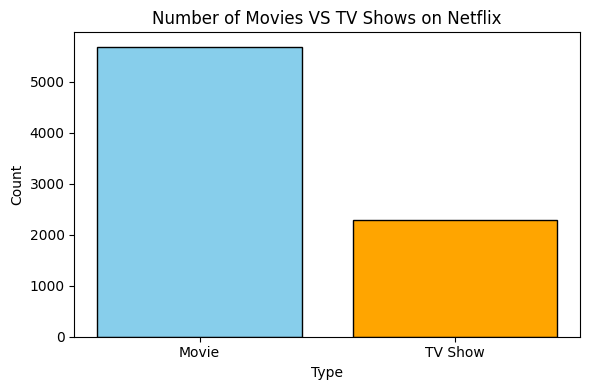

In [4]:
# Compare Movies and TV Shows

type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color = ['skyblue', 'orange'], edgecolor = 'black')
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

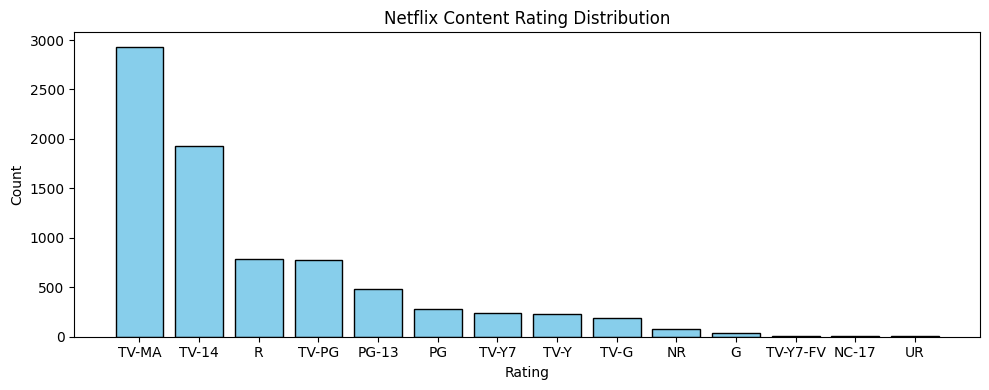

In [10]:
# Identify the Rating

rating_counts = df['rating'].value_counts() 
plt.figure(figsize=(10,4))
plt.bar(rating_counts.index, rating_counts.values, color = 'skyblue', edgecolor = 'Black')
plt.title('Netflix Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('rating_distribution.png')

plt.show()

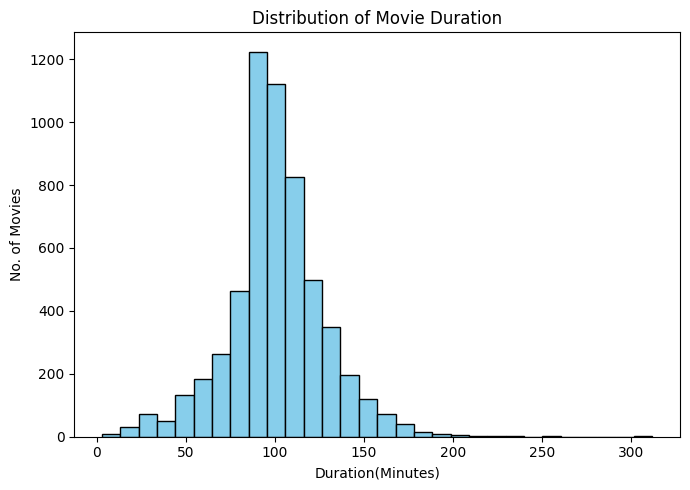

In [11]:
# Movies Duration Histogram

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min', '').astype(int)

plt.figure(figsize=(7,5))
plt.hist(movie_df['duration_int'], bins=30, color='skyblue', edgecolor = 'black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration(Minutes)')
plt.ylabel('No. of Movies')
plt.tight_layout()
plt.savefig('movie_duration_distribution.png')

plt.show()

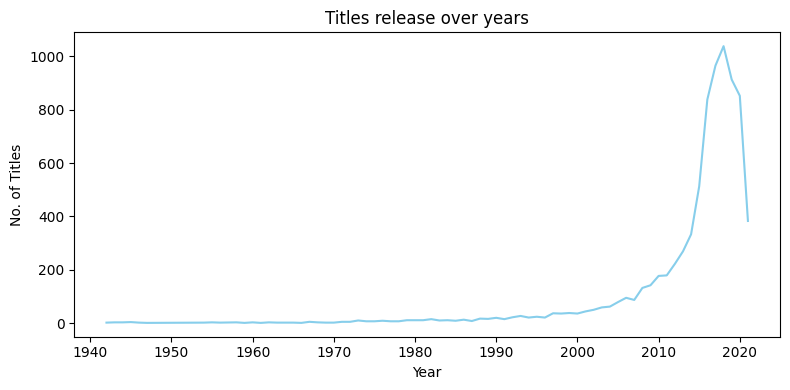

In [12]:
# Identify the trend of shows release per year

release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.plot(release_counts.index, release_counts.values, color = 'skyblue')
plt.title('Titles release over years')
plt.xlabel('Year')
plt.ylabel('No. of Titles')
plt.tight_layout()
plt.savefig('titles_release.png')

plt.show()

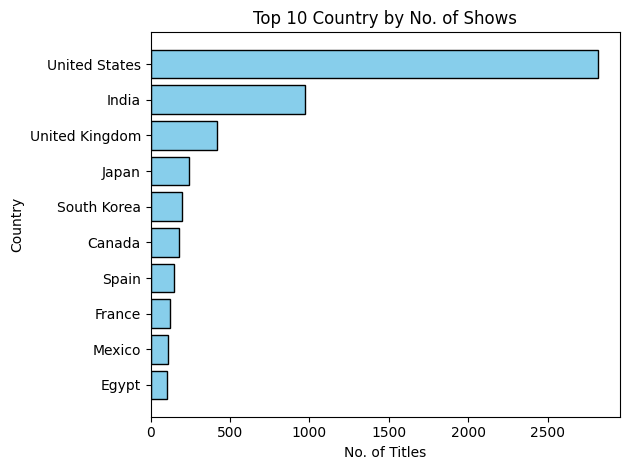

In [13]:
# Let's compare which countries are dominating the highest number of shows

country_counts = df['country'].value_counts().head(10).sort_values()

plt.barh(country_counts.index, country_counts.values, color = 'skyblue' , edgecolor = 'black')
plt.title('Top 10 Country by No. of Shows')
plt.xlabel('No. of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top_country.png')
plt.show()

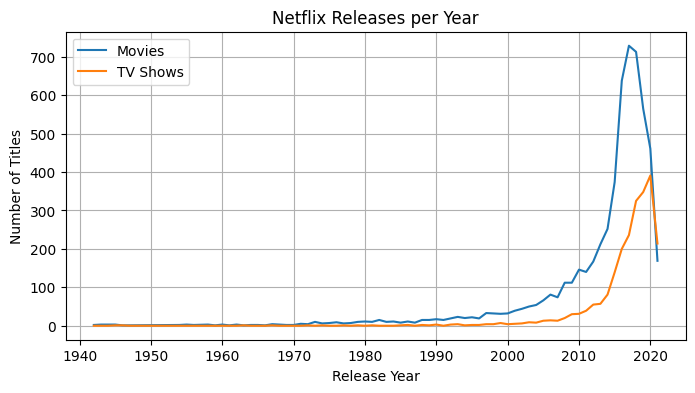

In [14]:
# Find the Netflix release per year(TV Shows, Movies) trend 

year_type_counts = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(8,4))

plt.plot(year_type_counts.index,
         year_type_counts['Movie'],
         label='Movies')

plt.plot(year_type_counts.index,
         year_type_counts['TV Show'],
         label='TV Shows')

plt.title('Netflix Releases per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True)
plt.savefig('netflix_release.png')

plt.show()
